In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv("data/train.csv",encoding="utf-8")
test_df = pd.read_csv("data/test.csv",encoding="utf-8")

In [3]:
train_df.shape

(891, 12)

In [4]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
test_df.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [6]:
test_df.shape

(418, 11)

In [7]:
train_df["train_col"] = 1
test_df["train_col"] = 0

In [8]:
merged_df = pd.concat([train_df,test_df],axis=0)

In [9]:
merged_df.shape

(1309, 13)

In [10]:
merged_df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
train_col         0
dtype: int64

In [11]:
age_df = merged_df.copy()

In [12]:
# age_df = age_df.drop(["Survived","Cabin"],axis=1)

In [12]:
age_df.dropna(subset=["Fare","Embarked"],inplace=True)

In [13]:
age_df.isna().sum()

PassengerId       0
Survived        417
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1013
Embarked          0
train_col         0
dtype: int64

In [14]:
get_name = age_df["Name"].apply(lambda x: x.split(",")[1])
get_title = get_name.apply(lambda x: x.split(".")[0])
age_df["Title"] = get_title

In [15]:
age_df["Title"].value_counts()

Title
Mr              756
Miss            259
Mrs             196
Master           61
Rev               8
Dr                8
Col               4
Ms                2
Major             2
Mlle              2
Don               1
Mme               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64

In [16]:
title_map = {
    "Mr": "Mr",
    "Miss": "Miss",
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mrs": "Mrs",
    "Mme": "Mrs",
    "Master": "Master",
    "Rev": "Rare",
    "Dr": "Rare",
    "Col": "Rare",
    "Major": "Rare",
    "Don": "Rare",
    "Dona": "Rare",
    "Lady": "Rare",
    "Sir": "Rare",
    "Capt": "Rare",
    "the Countess": "Rare",
    "Jonkheer": "Rare",
}

age_df["Title"] = age_df["Title"].str.strip().map(title_map)

In [17]:
age_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_col,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,Mr
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Mrs
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Mrs
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr


In [18]:
age_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train_col', 'Title'],
      dtype='str')

In [19]:
from sklearn.preprocessing import OrdinalEncoder

or_cols = ['Title','Embarked','Sex','Ticket']

scalers = {}
for col in or_cols:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    age_df[col] = enc.fit_transform(age_df[[col]])

age_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_col,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",1.0,22.0,1,0,718.0,7.2500,NaN,2.0,1,2.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.0,38.0,1,0,814.0,71.2833,C85,0.0,1,3.0
2,3,1.0,3,"Heikkinen, Miss. Laina",0.0,26.0,0,0,912.0,7.9250,NaN,2.0,1,1.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.0,35.0,1,0,64.0,53.1000,C123,2.0,1,3.0
4,5,0.0,3,"Allen, Mr. William Henry",1.0,35.0,0,0,647.0,8.0500,NaN,2.0,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",1.0,NaN,0,0,709.0,8.0500,NaN,2.0,0,2.0
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",0.0,39.0,0,0,832.0,108.9000,C105,0.0,0,4.0
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",1.0,38.5,0,0,870.0,7.2500,NaN,2.0,0,2.0
416,1308,NaN,3,"Ware, Mr. Frederick",1.0,NaN,0,0,578.0,8.0500,NaN,2.0,0,2.0


In [20]:
age_con = age_df["Age"].isna()

age_na = age_df[age_con]
age_not_na = age_df[~age_con]

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

iners = []
sil_scores = []

features = ["Pclass","Sex","SibSp","Parch","Ticket","Embarked","Title"]
data = age_df[features]

r = range(2,40)
for i in r:
    model = KMeans(n_clusters=i)
    model.fit(data)
    iner = model.inertia_
    sil_score = silhouette_score(data, model.predict(data))
    sil_scores.append(sil_score)
    iners.append(iner)
    print(f"n_clusters:{i}, sil_score:{sil_score}, inertia:{iner}")

n_clusters:2, sil_score:0.6488853669200084, inertia:22654277.126048837
n_clusters:3, sil_score:0.6066103087131817, inertia:9939148.79038477
n_clusters:4, sil_score:0.5864469748255469, inertia:5566725.133576351
n_clusters:5, sil_score:0.5814321934408118, inertia:3492520.7664426486
n_clusters:6, sil_score:0.5536685789829956, inertia:2641587.0507289097
n_clusters:7, sil_score:0.5517868139465593, inertia:1880112.5850132573
n_clusters:8, sil_score:0.531308395910907, inertia:1492032.8824614275
n_clusters:9, sil_score:0.5435972989296255, inertia:1118659.7743187882
n_clusters:10, sil_score:0.5385746375052837, inertia:947998.4386960494
n_clusters:11, sil_score:0.5375081633693757, inertia:818965.8121180126
n_clusters:12, sil_score:0.5432965099834846, inertia:635792.5114073758
n_clusters:13, sil_score:0.5390078861810298, inertia:535354.6313319614
n_clusters:14, sil_score:0.5383038586011185, inertia:465830.1067516591
n_clusters:15, sil_score:0.5285474960372649, inertia:433003.5031608308
n_clusters

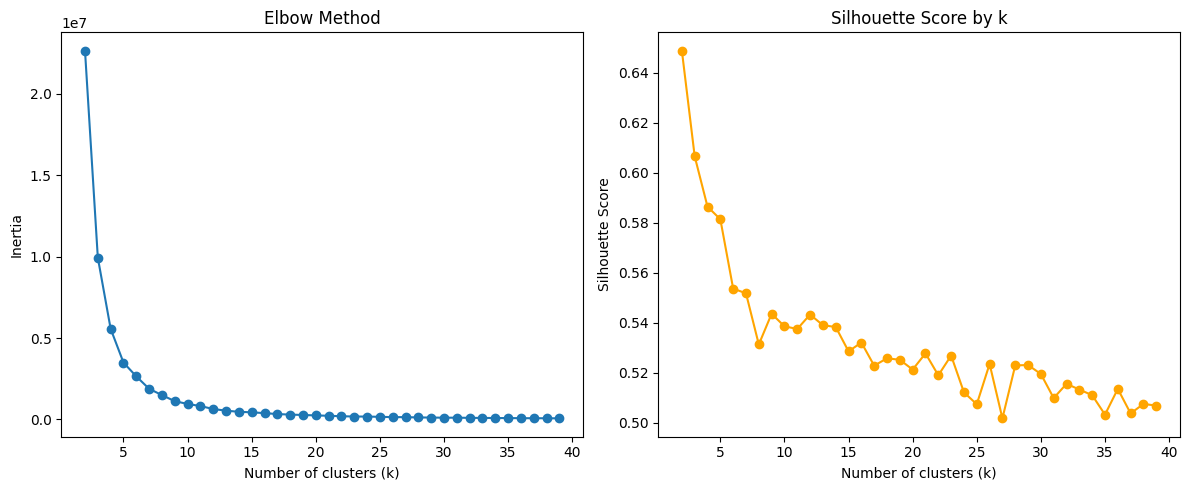

In [22]:
import matplotlib.pyplot as plt

k_range = r

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(k_range, iners, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(k_range, sil_scores, marker="o", color="orange")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()

In [23]:
for x in range(3,7,1):
    k_best = KMeans(n_clusters=x)
    clusters = k_best.fit_predict(age_df[features])
    age_df["cluster"] = clusters

    age_stats = age_df.groupby("cluster")["Age"].agg(["mean", "std", "var", "count"])
    print(age_stats)

              mean        std         var  count
cluster                                         
0        32.663945  14.976733  224.302542    365
1        25.889747  12.355917  152.668688    316
2        30.363729  14.640714  214.350511    362
              mean        std         var  count
cluster                                         
0        27.240448  13.173742  173.547490    201
1        24.833659  13.215605  174.652214    246
2        34.946221  14.352229  205.986475    299
3        30.511246  14.322706  205.139899    297
              mean        std         var  count
cluster                                         
0        25.533125  12.328558  151.993347    176
1        35.646971  14.375699  206.660711    241
2        30.674686  14.566600  212.185845    271
3        26.325000  13.728301  188.466253    210
4        28.754000  13.903318  193.302251    145
              mean        std         var  count
cluster                                         
0        24.975057  

In [24]:
k_best = KMeans(n_clusters=5)
clusters = k_best.fit_predict(age_df[features])
age_df["cluster"] = clusters

In [25]:
cluster_means = age_df.groupby("cluster")["Age"].transform("mean")
age_df["Age"] = age_df["Age"].fillna(cluster_means)

In [26]:
cluster_means

0      27.869177
1      30.760290
2      30.760290
3      35.713950
4      27.869177
         ...    
413    27.869177
414    30.760290
415    30.760290
416    27.869177
417    26.739950
Name: Age, Length: 1306, dtype: float64

In [27]:
age_df["Age"].isna().sum()

np.int64(0)

In [28]:
age_df.isna().sum()

PassengerId       0
Survived        417
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1013
Embarked          0
train_col         0
Title             0
cluster           0
dtype: int64